# Task 2: Gestalt principles of grouping
Object-oriented matplotlib only (`fig, ax = plt.subplots()`). Grey = context, one strong colour = message.
Data: `stimuli_gestalt.csv` (284 rows, six panels) and `tips.csv` (244 rows, none excluded).

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
d = pd.read_csv('stimuli_gestalt.csv')
if os.path.exists('tips.csv'):
    tips = pd.read_csv('tips.csv')
else:  # fallback: standard seaborn copy
    tips = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv')
GREY = '#8a8a8a'
order = ['proximity','similarity','enclosure','continuity','closure','connection']
print(d.groupby('panel').agg(items=('x','size'), groups=('group','nunique')).loc[order])

            items  groups
panel                    
proximity      48       4
similarity     48       4
enclosure      48       4
continuity     48       2
closure        44       2
connection     48      24


## 1. All six panels
Attributes relied on: **position** (proximity, enclosure, continuity, closure), **hue** (similarity; categorical, suited to hue), **line** (connection).
Closure keeps its 44 items (the gap is the stimulus). Similarity colours are *not* spatially separated. No rows excluded.

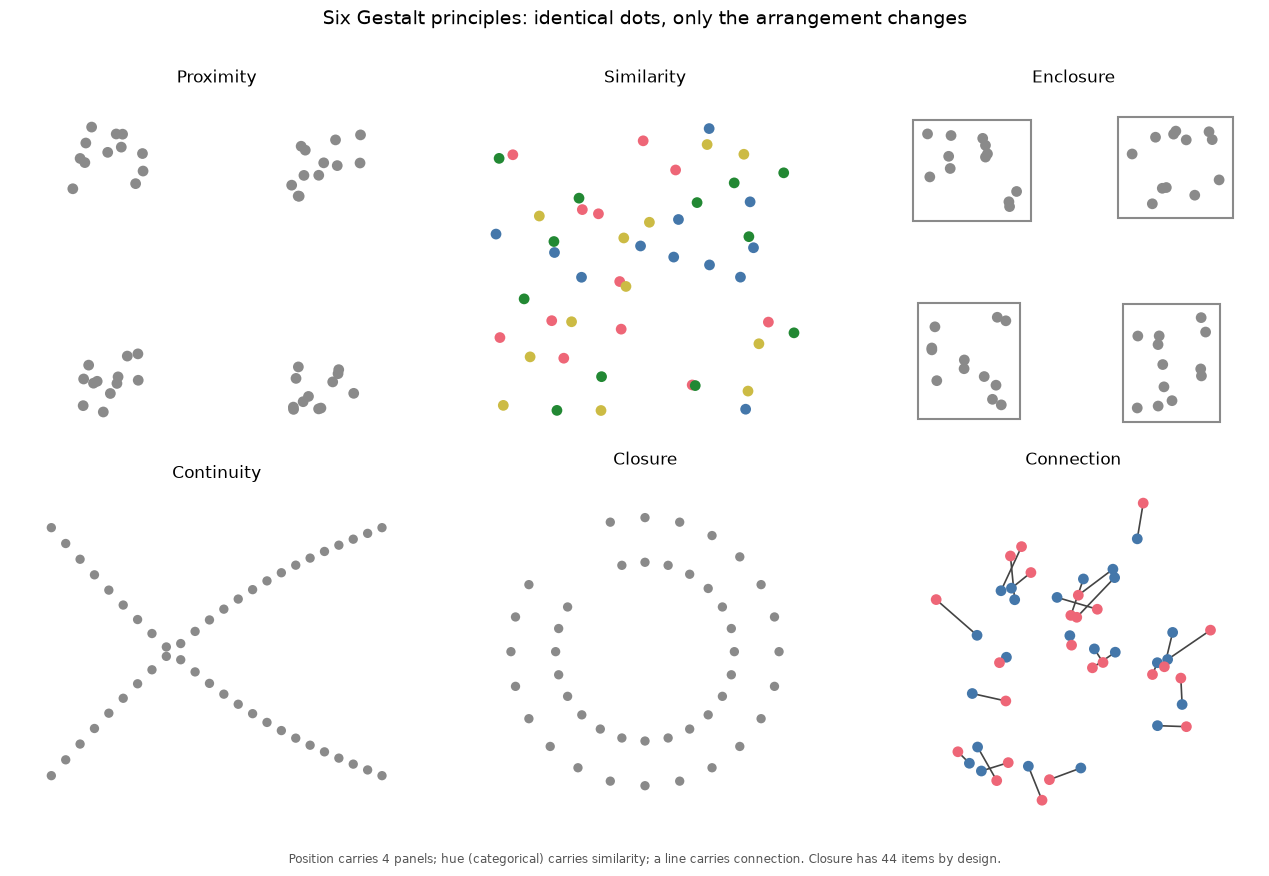

In [2]:
def draw(ax, p, lines=True, title=None):
    s = d[d.panel == p]
    col = s.colour.map(lambda c: GREY if c == 'grey' else c)
    if p == 'enclosure':
        pad = 0.35
        for _, g in s.groupby('group'):
            ax.add_patch(Rectangle((g.x.min()-pad, g.y.min()-pad),
                                   g.x.max()-g.x.min()+2*pad, g.y.max()-g.y.min()+2*pad,
                                   fill=False, edgecolor=GREY, lw=1.5))
    if p == 'connection' and lines:
        for _, g in s.groupby('connector'):
            ax.plot(g.x, g.y, color='#444444', lw=1.2, zorder=1)
    ax.scatter(s.x, s.y, c=col, s=s['size'], zorder=2, edgecolor='none')
    ax.set_title(title or p.capitalize(), fontsize=12)
    ax.set_xlim(s.x.min()-1, s.x.max()+1); ax.set_ylim(s.y.min()-1, s.y.max()+1)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

fig, axs = plt.subplots(2, 3, figsize=(13, 8.8))
for ax, p in zip(axs.ravel(), order): draw(ax, p)
fig.suptitle('Six Gestalt principles: identical dots, only the arrangement changes', fontsize=14)
fig.text(0.5, 0.01, 'Position carries 4 panels; hue (categorical) carries similarity; a line carries connection. Closure has 44 items by design.',
         ha='center', fontsize=8.5, color='#555')
fig.tight_layout(rect=[0, 0.03, 1, 0.96]); plt.show()

## 2. Perceived vs true groups
**Not collected: this needs a real person.** Show each panel above (without the answer), ask *"how many groups do you see?"*, and fill in the table.

In [3]:
truth = d.groupby('panel').group.nunique().loc[order]
res = pd.DataFrame({'principle': [p.capitalize() for p in order],
                    'true_groups': truth.values,
                    'perceived_groups': [None]*6})   # <- fill in
res['match'] = np.where(res.perceived_groups.isna(), '', np.where(res.perceived_groups == res.true_groups, 'yes', 'no'))
res

,principle,true_groups,perceived_groups,match
0,Proximity,4,None,
1,Similarity,4,None,
2,Enclosure,4,None,
3,Continuity,2,None,
4,Closure,2,None,
5,Connection,24,None,


## 3. Principles in conflict: connection vs similarity vs proximity
Same 48 dots, lines off then on. Ask your reader to group each. **Result is for you to record**; the stimulus check below shows why connection is the only cue for pairs.

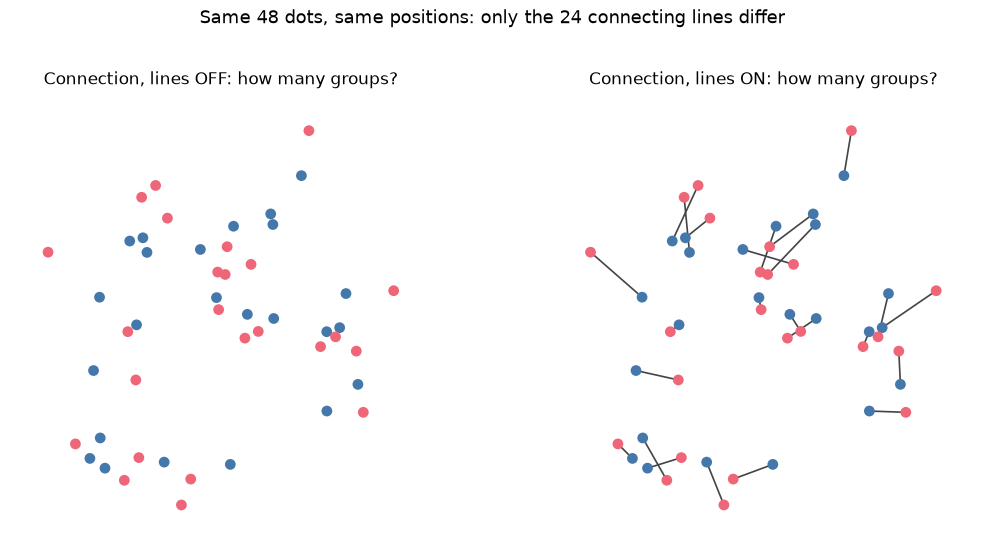

Nearest neighbour is the partner: 31%  (proximity opposes pairing)
Nearest neighbour has the other colour: 60%  (similarity opposes pairing)


In [4]:
fig, axs = plt.subplots(1, 2, figsize=(11, 5.6))
draw(axs[0], 'connection', False, 'Connection, lines OFF: how many groups?')
draw(axs[1], 'connection', True,  'Connection, lines ON: how many groups?')
fig.suptitle('Same 48 dots, same positions: only the 24 connecting lines differ', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

c = d[d.panel == 'connection'].reset_index(drop=True)
P = c[['x', 'y']].values
D = np.linalg.norm(P[:, None] - P[None], axis=2); np.fill_diagonal(D, 1e9)
nn = D.argmin(1)
print(f"Nearest neighbour is the partner: {(c.connector.values[nn]==c.connector.values).mean():.0%}  (proximity opposes pairing)")
print(f"Nearest neighbour has the other colour: {(c.colour.values[nn]!=c.colour.values).mean():.0%}  (similarity opposes pairing)")

Reader result (fill in): lines OFF → ___ ; lines ON → ___ ; winner → ___

## 4. Proximity in a real chart (tips.csv)
**Principle:** proximity (within-day gap 0 < between-day gap 1.0). **Attribute:** hue for sex (categorical, suited). **Pop-out:** Female in the one strong colour; Male in grey.
**Ink removed:** top/right spines, gridlines (carried no information). Bars start at zero, one y-axis. No rows excluded.

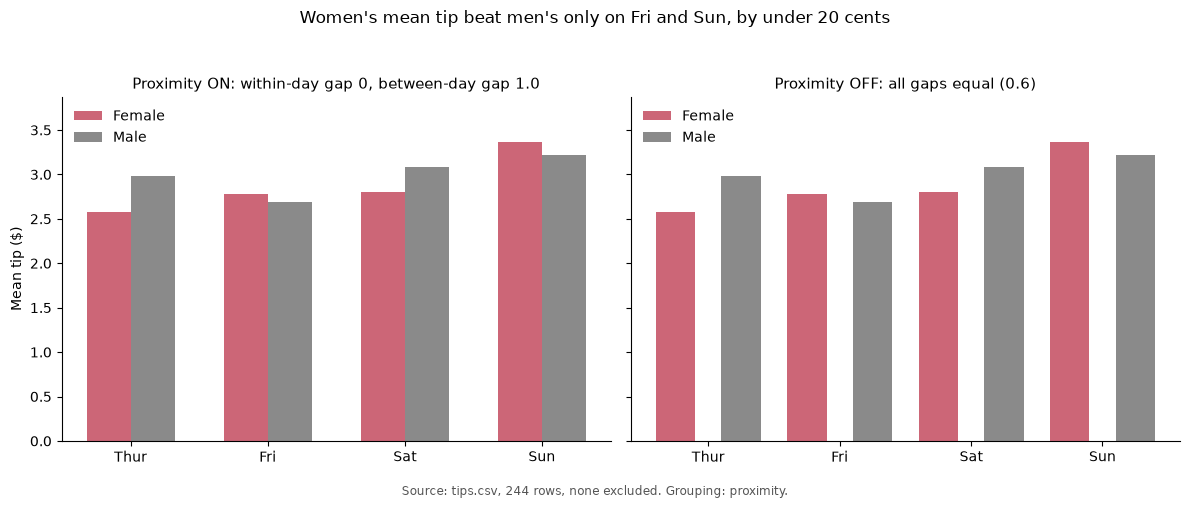

sex,Female,Male
day,,
Thur,2.58,2.98
Fri,2.78,2.69
Sat,2.80,3.08
Sun,3.37,3.22


In [5]:
days = ['Thur', 'Fri', 'Sat', 'Sun']
m = tips.groupby(['day', 'sex'], observed=True).tip.mean().unstack().loc[days]
def bars(ax, gap_in, gap_out, title):
    w, x, ticks = 0.9, 0, []
    for day in days:
        for k, (sex, colr) in enumerate([('Female', '#cc6677'), ('Male', GREY)]):
            ax.bar(x, m.loc[day, sex], width=w, color=colr, label=sex if day == 'Thur' else None)
            if k == 0: x0 = x
            x += w + gap_in
        ticks.append((x0 + x - gap_in - w) / 2); x += gap_out - gap_in
    ax.set_xticks(ticks); ax.set_xticklabels(days)
    ax.set_ylim(0, m.values.max()*1.15); ax.set_ylabel('Mean tip ($)'); ax.set_title(title, fontsize=11)
    for s in ['top', 'right']: ax.spines[s].set_visible(False)
    ax.legend(frameon=False, loc='upper left')

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bars(axs[0], 0.0, 1.0, 'Proximity ON: within-day gap 0, between-day gap 1.0')
bars(axs[1], 0.6, 0.6, 'Proximity OFF: all gaps equal (0.6)'); axs[1].set_ylabel('')
fig.suptitle("Women's mean tip beat men's only on Fri and Sun, by under 20 cents", fontsize=12)
fig.text(0.5, 0.01, f'Source: tips.csv, {len(tips)} rows, none excluded. Grouping: proximity.', ha='center', fontsize=8.5, color='#555')
fig.tight_layout(rect=[0, 0.04, 1, 0.94]); plt.show()
m.round(2)

**What the reader loses in the equal-gap version:** the days stop reading as units. Eight bars float at equal distance, so the Female-vs-Male comparison within a day needs the legend and a hunt for pairs. The numbers are identical; the work moves from the eye to working memory.

## 5. Where each principle already lives in a chart
- **Proximity:** bars of one category sit together in a grouped bar chart, with a wider gap between categories.
- **Similarity:** marks sharing a hue in a legend-keyed chart read as one series.
- **Enclosure:** a shaded band or box around a highlighted region (e.g. a recession period) makes everything inside read as one thing.
- **Closure:** a dashed outline or partial frame still reads as complete; a partly drawn gauge ring reads as a full circle.
- **Continuity:** the eye follows a line chart's line through its points as one trend.
- **Connection:** the line joining paired points in a slope chart or dumbbell plot links before to after; a table's row rules link the cells of a row.

## The legend question
Direct labelling uses **proximity** (plus connection if there is a leader line): the name sits next to the mark.

- **Legend:** see the mark → jump to the legend → match the swatch → read the name → hold the mapping in working memory → return. Every extra series adds a mapping to hold and another gaze jump plus recall.
- **Direct label:** the name is already beside the mark, so grouping is part of the display. Nothing to remember or match.

Direct labels replace a memory-and-match step with automatic perception. Working-memory load stays flat as series are added, while the legend's cost grows with series count. That is a difference in cognitive load, not preference.